In [1]:
import pandas as pd
from pathlib import Path

In [16]:
caminho = "base_meses_2026"

In [19]:
pasta = Path(caminho)
if not pasta.exists():
    raise FileNotFoundError(
        f"Caminho não encontrado: {pasta}"
    )
arq_meses = sorted(
    f for f in pasta.iterdir()
)
if not arq_meses:
    raise FileNotFoundError(
        f"Nenhum arquivo foi encontrado na pasta: {pasta}"
    )
print(f"{len(arq_meses)} arquivos encontrados")
    
df_meses_delivery = pd.DataFrame()
for arquivo_mes in arq_meses:
    df_mes = pd.read_csv(arquivo_mes)
    df_meses_delivery = pd.concat([df_mes, df_meses_delivery])
    
df_meses_delivery["Time"] = pd.to_datetime(df_meses_delivery["Time"])
df_meses_delivery = (
    df_meses_delivery.drop_duplicates(subset="Time", keep="last")
    .sort_values("Time")
    .reset_index(drop=True)
)


10 arquivos encontrados


In [25]:
df_meses_delivery.to_csv("food_delivery_sp_2026.csv", index=False)

In [20]:
df_meses_delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Time           281 non-null    datetime64[us]
 1   Food delivery  281 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 4.5 KB


In [23]:
df_meses_delivery.head()

,Time,Food delivery
0,2026-01-01,0
1,2026-01-02,82
2,2026-01-03,0
3,2026-01-04,0
4,2026-01-05,0


In [24]:
df_meses_delivery.tail()

,Time,Food delivery
276,2026-10-04,80
277,2026-10-05,87
278,2026-10-06,73
279,2026-10-07,98
280,2026-10-08,76


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = df_meses_delivery.rename(columns={"Time": "data", "Food delivery": "v"}).copy()
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.to_period("M")
rotulos = [p.strftime("%b") for p in sorted(df["mes"].unique())]

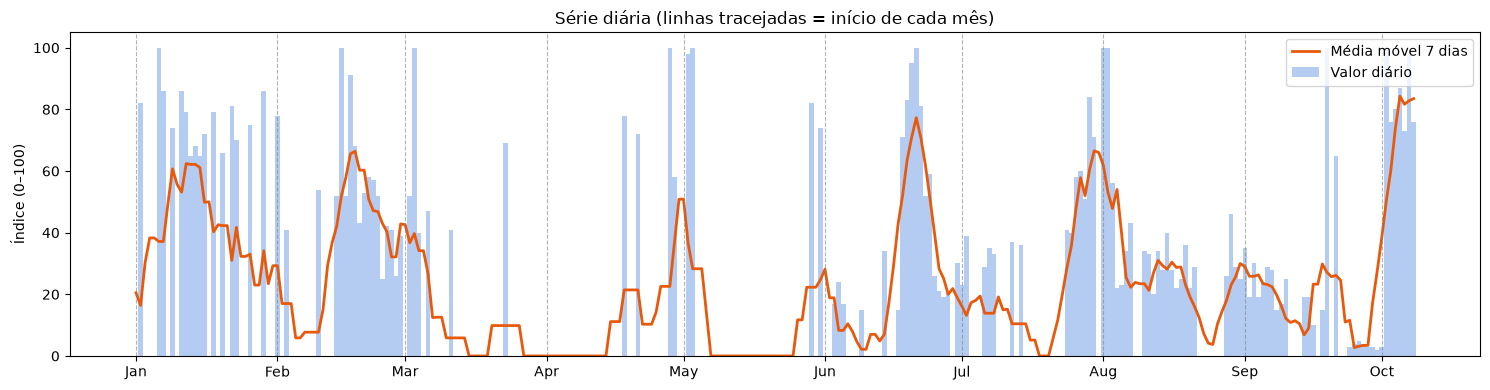

In [27]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(df["data"], df["v"], color="#2a6fdb", alpha=0.35, width=1, label="Valor diário")
ax.plot(df["data"], df["v"].rolling(7, center=True, min_periods=1).mean(),
        color="#e8590c", lw=2, label="Média móvel 7 dias")
for d in pd.date_range(df["data"].min(), df["data"].max(), freq="MS"):
    ax.axvline(d, color="gray", lw=0.8, ls="--", alpha=0.6)
ax.set_title("Série diária (linhas tracejadas = início de cada mês)")
ax.set_ylabel("Índice (0–100)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- caminhos ----------
# Se o notebook está em new_data/delivery, a raiz do repo é dois níveis acima.
# Se rodar de outro lugar, troque por Path("caminho/para/Analise-Climatica-Brasil")
RAIZ = Path.cwd().parents[1]
ARQ_DELIVERY = RAIZ / "new_data" / "delivery" / "food_delivery_sp_2026.csv"
ARQ_CHUVA = RAIZ / "data" / "gold" / "ddm_clima_sp_2026-01-01_2026-09-20.csv"

MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai",
         6: "Jun", 7: "Jul", 8: "Ago", 9: "Set", 10: "Out"}

# ---------- delivery ----------
delivery = pd.read_csv(ARQ_DELIVERY, parse_dates=["Time"])
delivery = delivery.rename(columns={"Time": "data", "Food delivery": "pesquisas"})
delivery["mes"] = delivery["data"].dt.month

# ---------- chuva (gold 2026) ----------
chuva = pd.read_csv(ARQ_CHUVA, parse_dates=["Data"])
chuva = chuva.rename(columns={"Data": "data", "Chuva_total": "chuva_mm"})
chuva = chuva[["data", "mes", "chuva_mm"]]

# ---------- junção (apenas dias presentes nos dois arquivos) ----------
base = delivery[["data", "pesquisas"]].merge(chuva[["data", "chuva_mm"]], on="data", how="inner")

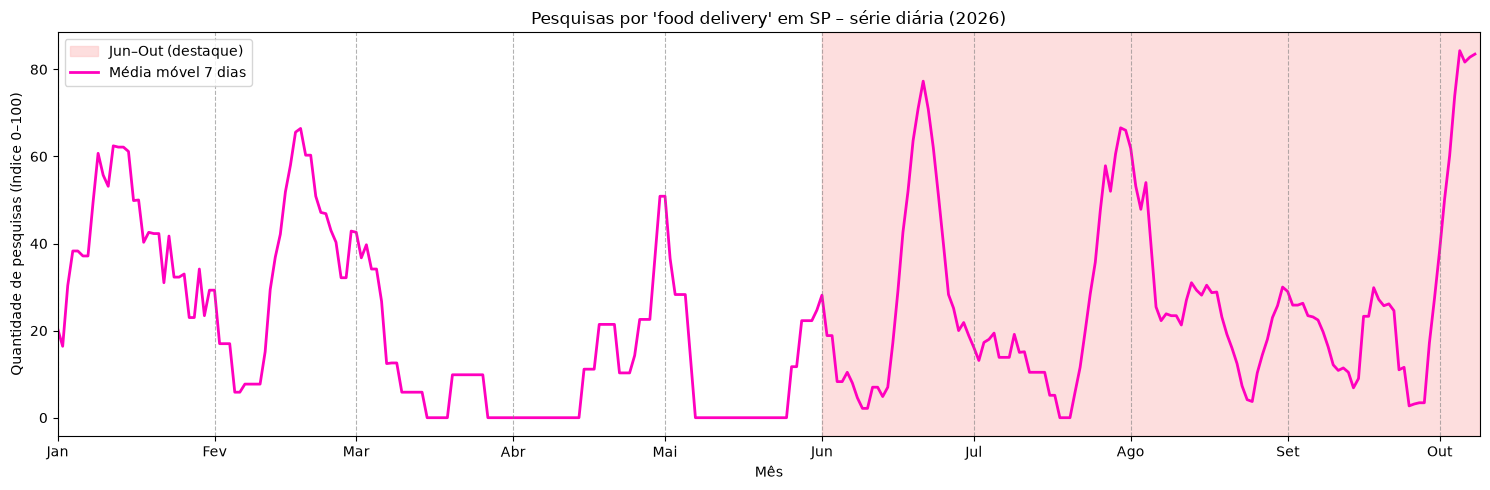

In [46]:
fig, ax = plt.subplots(figsize=(15, 5))

COR_2025, COR_2026 = "#672F8A", "#ff00be"

ax.axvspan(pd.Timestamp("2026-06-01"), delivery["data"].max() + pd.Timedelta(days=1),
           color="#fdc8c8", alpha=0.6, label="Jun–Out (destaque)")
ax.plot(delivery["data"], delivery["pesquisas"].rolling(7, center=True, min_periods=1).mean(),
        color="#ff00be", lw=2, label="Média móvel 7 dias")

for d in pd.date_range(delivery["data"].min(), delivery["data"].max(), freq="MS"):
    ax.axvline(d, color="gray", lw=0.8, ls="--", alpha=0.6)

ax.set_xlim(delivery["data"].min(), delivery["data"].max() + pd.Timedelta(days=1))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: MESES[mdates.num2date(x).month]))
ax.set_title("Pesquisas por 'food delivery' em SP – série diária (2026)")
ax.set_ylabel("Quantidade de pesquisas (índice 0–100)")
ax.set_xlabel("Mês")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---


In [ ]:
#%pip install scipy

In [ ]:
# ---------- dados: pesquisas + variáveis climáticas (dias em comum) ----------
clima = pd.read_csv(ARQ_CHUVA, parse_dates=["Data"]).rename(columns={"Data": "data"})
dados = delivery[["data", "pesquisas"]].merge(
    clima[["data", "Temperatura_maxima", "Temperatura_minima",
           "Velocidade_vento_max", "Chuva_total"]],
    on="data", how="inner",
)
dados = dados.rename(columns={
    "pesquisas": "Pesquisas",
    "Temperatura_maxima": "T.Máxima",
    "Temperatura_minima": "T.Mínima",
    "Velocidade_vento_max": "Vel. Vento",
    "Chuva_total": "Chuva",
})

dados = dados[dados["Pesquisas"] > 0]   # <-- só dias com pesquisas maiores que 0

corr = dados.drop(columns="data").corr()

# ---------- matriz de correlação (quadrados) ----------
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

nomes = corr.columns
ax.set_xticks(range(len(nomes)), labels=nomes)
ax.set_yticks(range(len(nomes)), labels=nomes)

for i in range(len(nomes)):
    for j in range(len(nomes)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=12)

ax.set_xticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
ax.grid(which="major", visible=False)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Correlação (pesquisas > 0): delivery × clima (SP, 2026, n = {len(dados)} dias)")
plt.tight_layout()
plt.show()

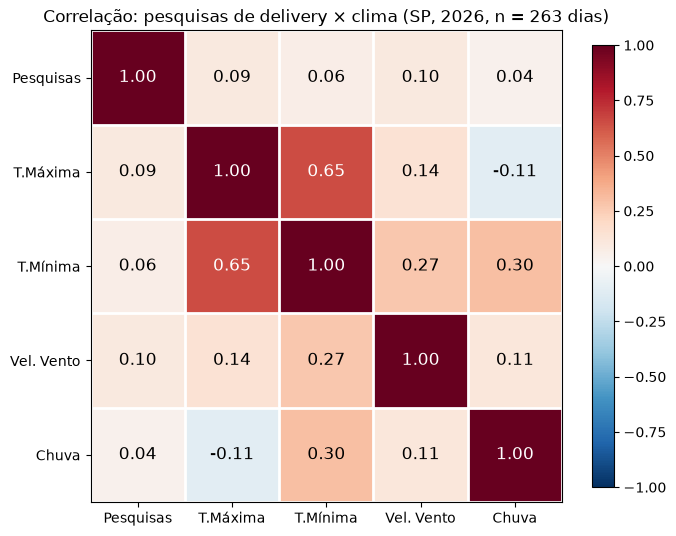

In [38]:
# ---------- dados: pesquisas + variáveis climáticas (dias em comum) ----------
clima = pd.read_csv(ARQ_CHUVA, parse_dates=["Data"]).rename(columns={"Data": "data"})
dados = delivery[["data", "pesquisas"]].merge(
    clima[["data", "Temperatura_maxima", "Temperatura_minima",
           "Velocidade_vento_max", "Chuva_total"]],
    on="data", how="inner",
)
dados = dados.rename(columns={
    "pesquisas": "Pesquisas",
    "Temperatura_maxima": "T.Máxima",
    "Temperatura_minima": "T.Mínima",
    "Velocidade_vento_max": "Vel. Vento",
    "Chuva_total": "Chuva",
})

# Pearson (para Spearman sem scipy, troque por: dados.drop(columns="data").rank().corr())
corr = dados.drop(columns="data").corr()

# ---------- matriz de correlação (quadrados) ----------
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

nomes = corr.columns
ax.set_xticks(range(len(nomes)), labels=nomes)
ax.set_yticks(range(len(nomes)), labels=nomes)

for i in range(len(nomes)):
    for j in range(len(nomes)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=12)

# linhas brancas separando os quadrados
ax.set_xticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
ax.grid(which="major", visible=False)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Correlação: pesquisas de delivery × clima (SP, 2026, n = {len(dados)} dias)")
plt.tight_layout()
plt.show()

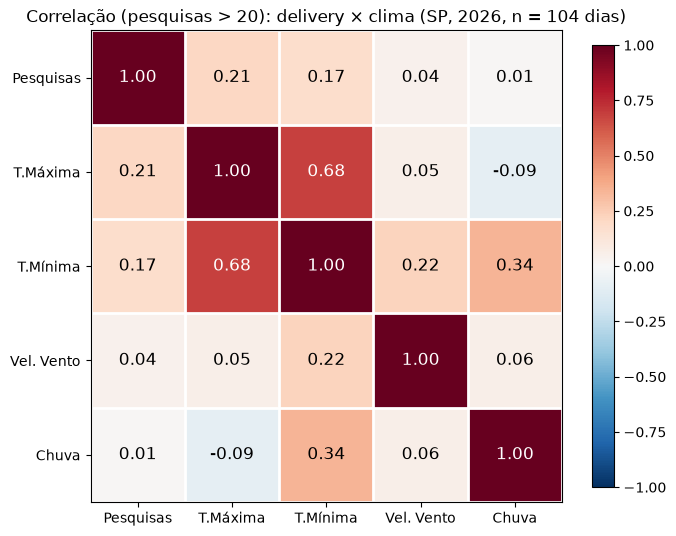

In [39]:
# ---------- dados: pesquisas + variáveis climáticas (dias em comum) ----------
LIMITE = 20  # só dias com mais de 20 pesquisas

clima = pd.read_csv(ARQ_CHUVA, parse_dates=["Data"]).rename(columns={"Data": "data"})
dados = delivery[["data", "pesquisas"]].merge(
    clima[["data", "Temperatura_maxima", "Temperatura_minima",
           "Velocidade_vento_max", "Chuva_total"]],
    on="data", how="inner",
)
dados = dados.rename(columns={
    "pesquisas": "Pesquisas",
    "Temperatura_maxima": "T.Máxima",
    "Temperatura_minima": "T.Mínima",
    "Velocidade_vento_max": "Vel. Vento",
    "Chuva_total": "Chuva",
})

dados = dados[dados["Pesquisas"] > LIMITE]

corr = dados.drop(columns="data").corr()

# ---------- matriz de correlação (quadrados) ----------
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

nomes = corr.columns
ax.set_xticks(range(len(nomes)), labels=nomes)
ax.set_yticks(range(len(nomes)), labels=nomes)

for i in range(len(nomes)):
    for j in range(len(nomes)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=12)

ax.set_xticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(nomes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
ax.grid(which="major", visible=False)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f"Correlação (pesquisas > {LIMITE}): delivery × clima (SP, 2026, n = {len(dados)} dias)")
plt.tight_layout()
plt.show()

---

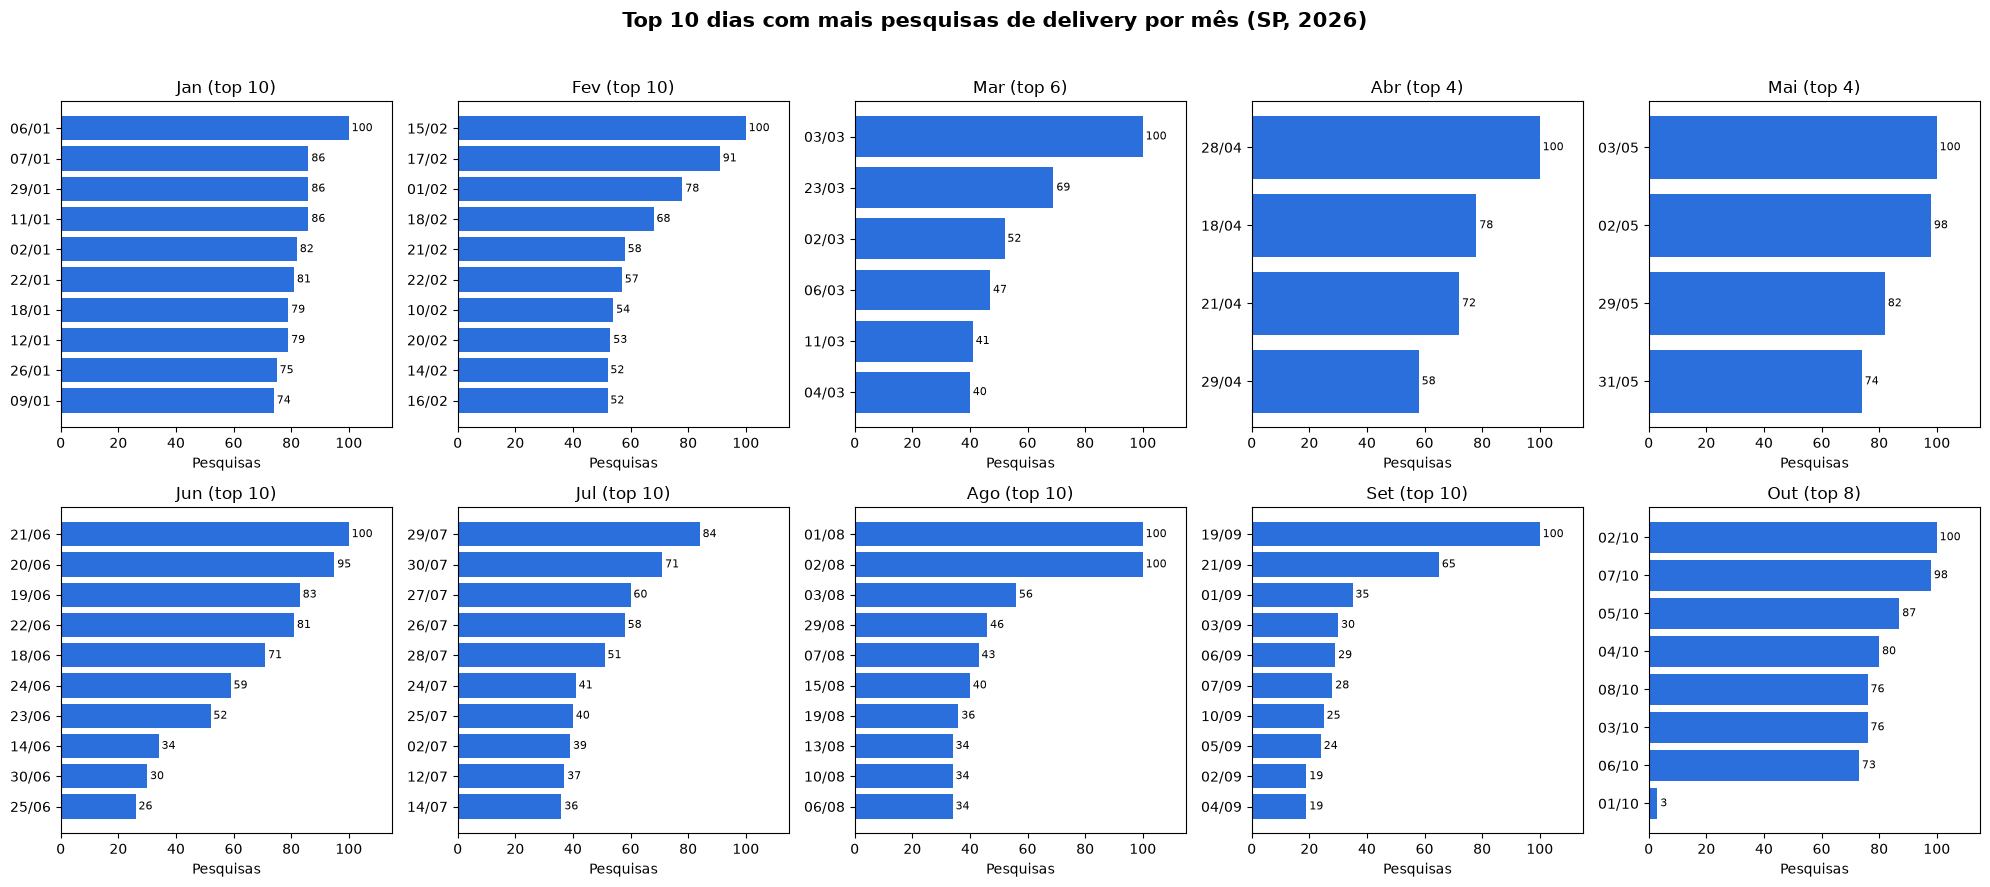

In [32]:
meses = sorted(delivery["mes"].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

for ax, m in zip(axes.flat, meses):
    top = (delivery[(delivery["mes"] == m) & (delivery["pesquisas"] > 0)]
           .nlargest(10, "pesquisas")
           .sort_values("pesquisas"))
    ax.barh(top["data"].dt.strftime("%d/%m"), top["pesquisas"], color="#2a6fdb")
    for i, v in enumerate(top["pesquisas"]):
        ax.text(v + 1, i, str(v), va="center", fontsize=8)
    ax.set_title(f"{MESES[m]} (top {len(top)})")
    ax.set_xlim(0, 115)
    ax.set_xlabel("Pesquisas")

for ax in axes.flat[len(meses):]:
    ax.axis("off")

fig.suptitle("Top 10 dias com mais pesquisas de delivery por mês (SP, 2026)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

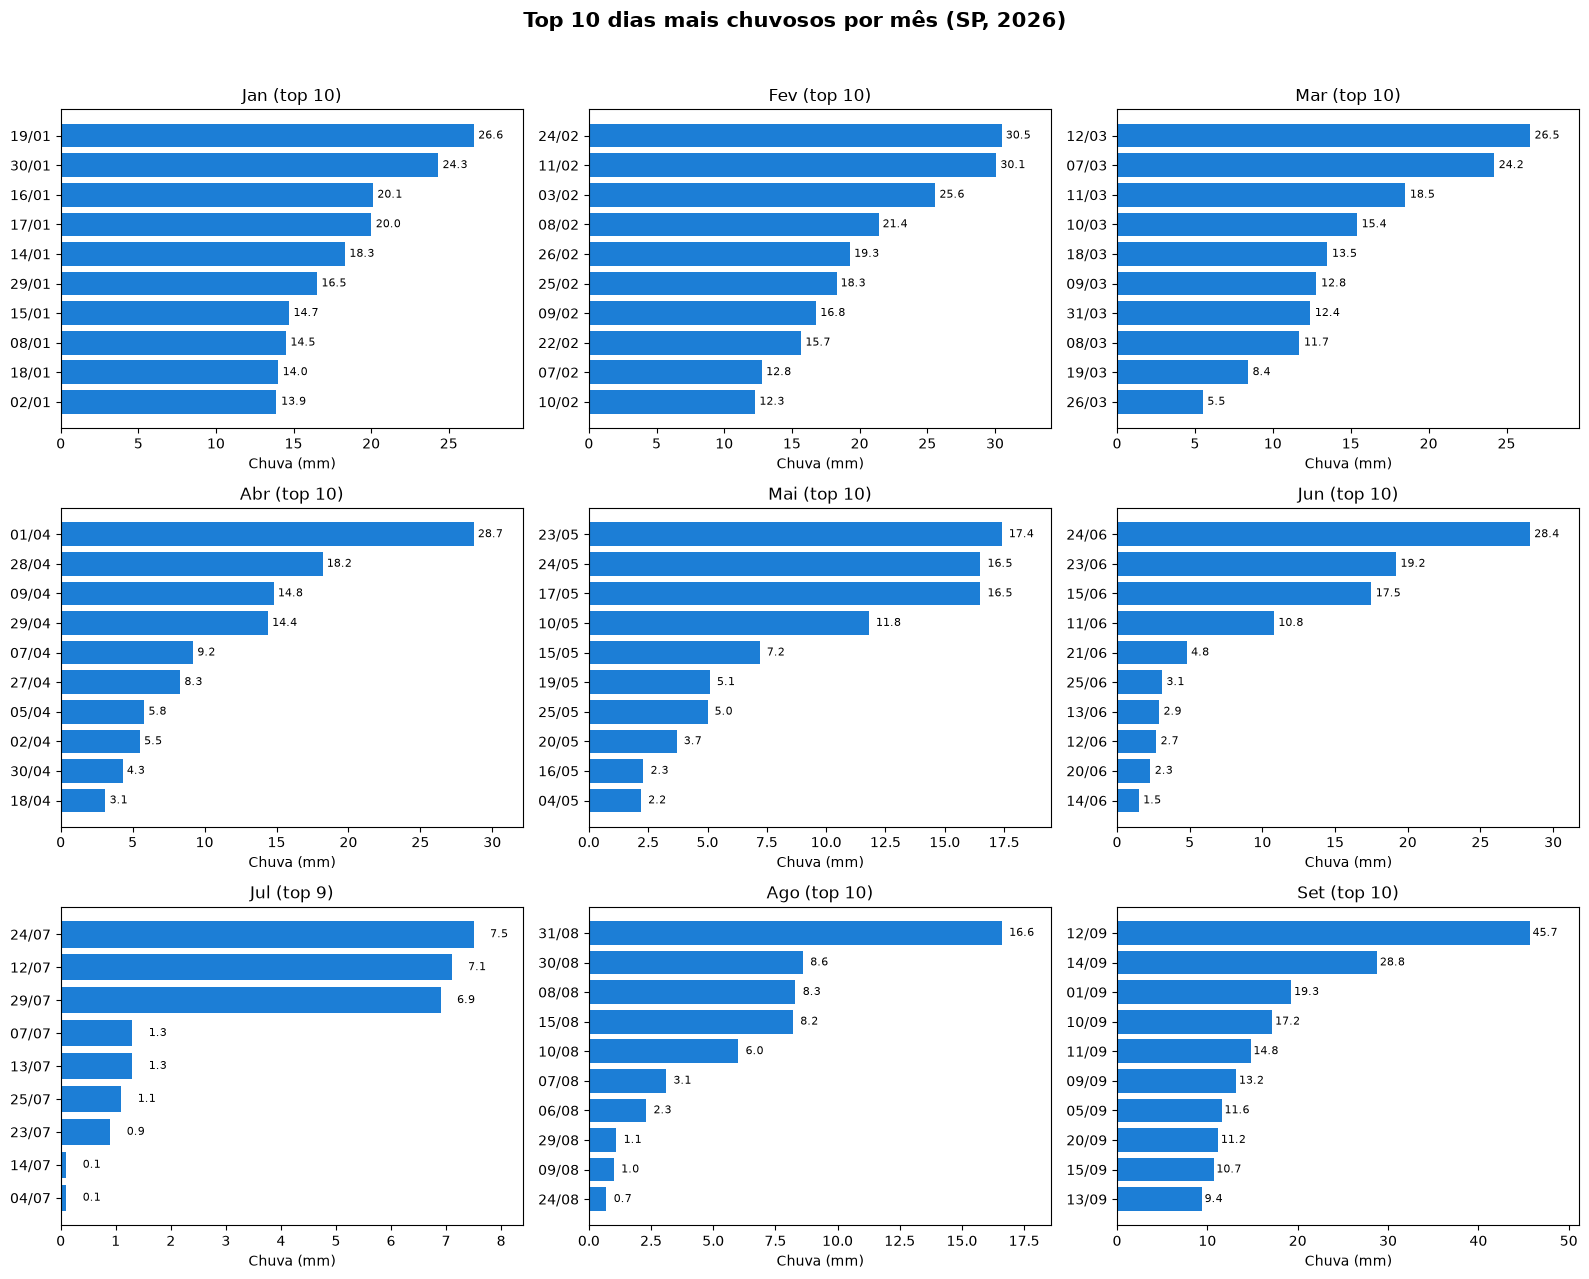

In [33]:
meses = sorted(chuva["mes"].unique())
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

for ax, m in zip(axes.flat, meses):
    top = (chuva[(chuva["mes"] == m) & (chuva["chuva_mm"] > 0)]
           .nlargest(10, "chuva_mm")
           .sort_values("chuva_mm"))
    ax.barh(top["data"].dt.strftime("%d/%m"), top["chuva_mm"], color="#1c7ed6")
    for i, v in enumerate(top["chuva_mm"]):
        ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=8)
    ax.set_xlim(0, top["chuva_mm"].max() * 1.12)
    ax.set_title(f"{MESES[m]} (top {len(top)})")
    ax.set_xlabel("Chuva (mm)")

for ax in axes.flat[len(meses):]:
    ax.axis("off")

fig.suptitle("Top 10 dias mais chuvosos por mês (SP, 2026)", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Gráfico salvo em grafico_4_top10_dias_mais_quentes_por_mes.png


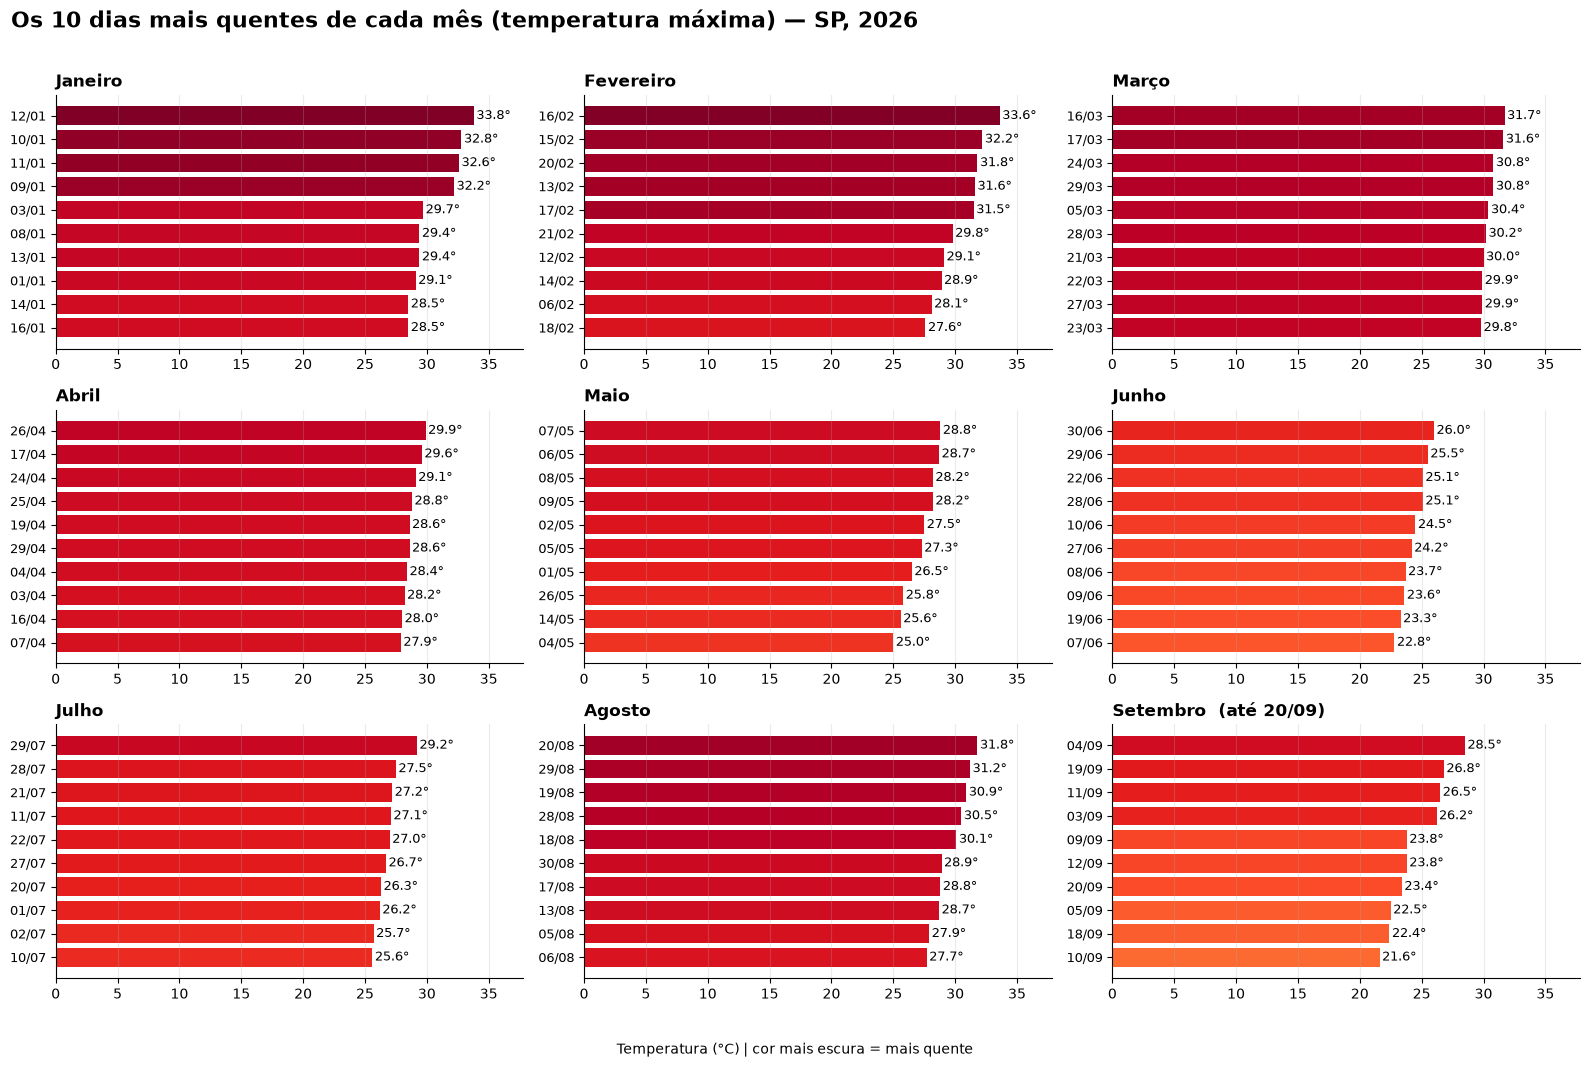

In [48]:
"""
Gráfico 4 - Os 10 dias mais quentes de cada mês (SP, 2026)
Critério: maior temperatura máxima do dia (troque COLUNA_CALOR por
'Temperatura_media' se preferir ranquear pela média diária).

Rodar na raiz do repositório:  python grafico_4_top10_dias_mais_quentes_por_mes.py
"""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------- configuração -------------------------
RAIZ = Path(".")
ARQ_CLIMA = ARQ_CHUVA
SAIDA = Path("grafico_4_top10_dias_mais_quentes_por_mes.png")
COLUNA_CALOR = "Temperatura_maxima"
TOP_N = 10
COLUNAS = 3
MESES_PT = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho", "Julho",
            "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]
# ----------------------------------------------------------------

df = pd.read_csv(ARQ_CLIMA, parse_dates=["Data"]).rename(columns={"Data": "data"})
df["mes"] = df["data"].dt.month

meses = sorted(df["mes"].unique())
linhas = -(-len(meses) // COLUNAS)
fig, axes = plt.subplots(linhas, COLUNAS, figsize=(16, 3.6 * linhas))
axes = axes.flatten()

vmin, vmax = df[COLUNA_CALOR].min(), df[COLUNA_CALOR].max()
cmap = plt.get_cmap("YlOrRd")

for ax, mes in zip(axes, meses):
    g = df[df["mes"] == mes]
    top = g.sort_values([COLUNA_CALOR, "data"], ascending=[False, True]).head(TOP_N).iloc[::-1]
    cores = [cmap(0.25 + 0.75 * (v - vmin) / (vmax - vmin)) for v in top[COLUNA_CALOR]]

    ax.barh(top["data"].dt.strftime("%d/%m"), top[COLUNA_CALOR], color=cores)
    for y, v in enumerate(top[COLUNA_CALOR]):
        ax.text(v + 0.2, y, f"{v:.1f}°", va="center", fontsize=9)
    ax.set_xlim(0, vmax + 4)
    titulo = MESES_PT[mes - 1]
    if g["data"].max().day < 28 and mes == df["mes"].max():
        titulo += f"  (até {g['data'].max():%d/%m})"
    ax.set_title(titulo, fontsize=12, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    ax.tick_params(axis="y", labelsize=9)

for ax in axes[len(meses):]:
    ax.axis("off")

rotulo = "temperatura máxima" if COLUNA_CALOR == "Temperatura_maxima" else "temperatura média"
fig.suptitle(f"Os 10 dias mais quentes de cada mês ({rotulo}) — SP, 2026",
             fontsize=16, fontweight="bold", x=0.01, ha="left")
fig.supxlabel("Temperatura (°C) | cor mais escura = mais quente", fontsize=10)
plt.tight_layout(rect=(0, 0.02, 1, 0.97))
plt.savefig(SAIDA, dpi=150)
print(f"Gráfico salvo em {SAIDA}")
plt.show()